# Student Score Prediction 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score


Load the dataset

In [17]:
data = pd.read_csv("data/student_performance.csv")

X = data[['study_hours',
        'self_study_hours',
        'sleep_hours',
        'focus_index',
        'burnout_level',
        'productivity_score',
        'mental_health_score',
        'screen_time_hours',
        'social_media_hours',
        'gaming_hours'
    ]]

y = data['exam_score']

Train the Model

In [18]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Predict on the test

In [19]:
y_pred = model.predict(X_test)

Evaluation

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("Mean Absoulte Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse))
print("r2_score:", round(r2, 2))

Mean Absoulte Error (MAE): 4.01
Mean Squared Error (MSE): 25.79
Root Mean Squared Error (RMSE): 5
r2_score: 0.81


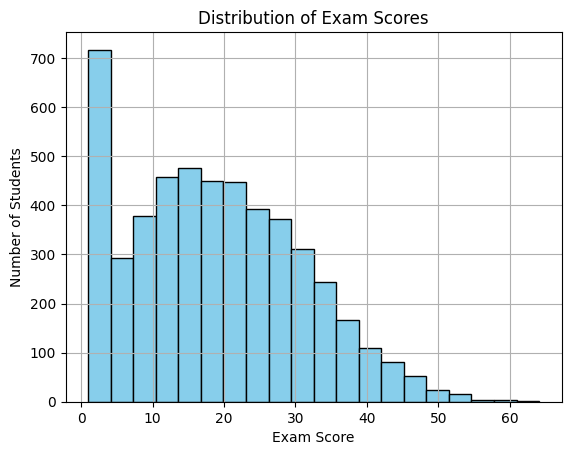

In [21]:
# Histogram

plt.Figure(figsize = (10,6))
plt.hist(data["exam_score"],bins=20,color='skyblue',edgecolor='black')
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

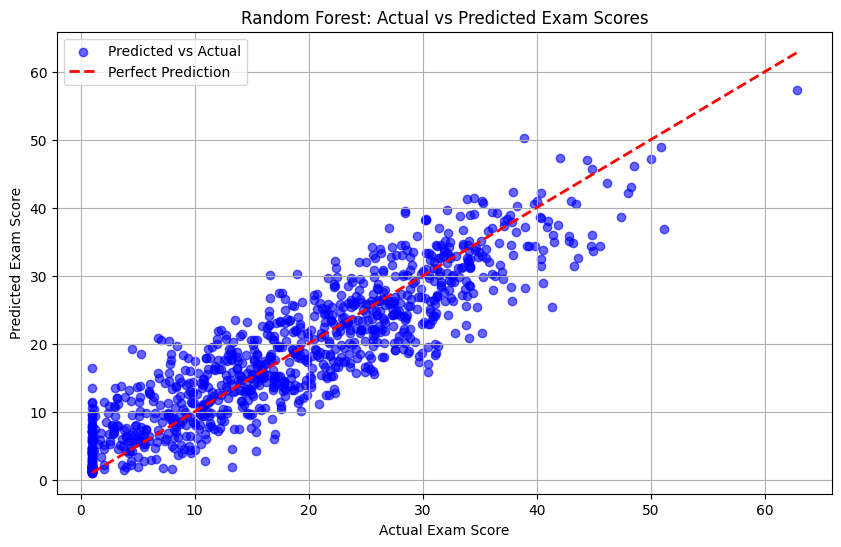

In [23]:

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Random Forest: Actual vs Predicted Exam Scores")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
new_students = pd.DataFrame([
    {
        'study_hours': 9,
        'self_study_hours': 2,
        'sleep_hours': 7,
        'focus_index': 0.85,
        'burnout_level': 0.2,
        'productivity_score': 80,
        'mental_health_score': 70,
        'screen_time_hours': 4,
        'social_media_hours': 2,
        'gaming_hours': 1
    },
    {
        'study_hours': 6,
        'self_study_hours': 1,
        'sleep_hours': 6,
        'focus_index': 0.65,
        'burnout_level': 0.5,
        'productivity_score': 70,
        'mental_health_score': 60,
        'screen_time_hours': 5,
        'social_media_hours': 3,
        'gaming_hours': 2
    }
])

predicted_new_scores = model.predict(new_students)
for i, score in enumerate(predicted_new_scores):
    print(f"Predicted exam score for student {i+1}: {score:.2f}")

Predicted exam score for student 1: 46.31
Predicted exam score for student 2: 39.73
